In [48]:
# connect to my google drive to read dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import pandas as pd

url = "/content/drive/My Drive/Colab Notebooks/CS4375_Project/data/"

train = pd.read_csv(url+"exoTrain.csv")
test  = pd.read_csv(url+"exoTest.csv")

print(train.shape, test.shape)

(5087, 3198) (570, 3198)


In [50]:
train.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [51]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


In [52]:
train.isna().sum().sum()
# result = 0 -> no missing values

np.int64(0)

In [53]:
# count how many samples in each class
# see if dataset is balanced or not
train["LABEL"].value_counts()

,count
LABEL,
1,5050
2,37


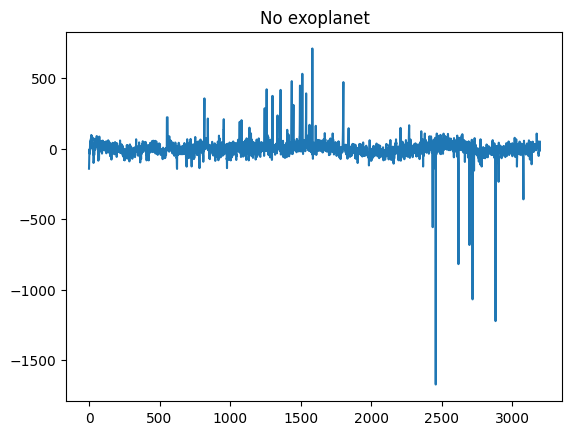

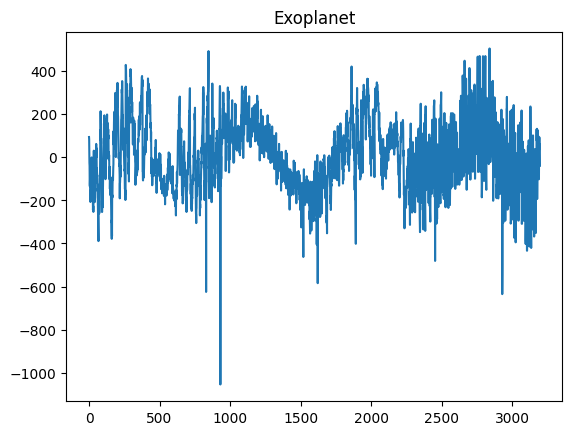

In [54]:
import matplotlib.pyplot as plt

# plot 1 example from each class to see difference in shape

# class 1 (no exoplanet)
plt.plot(train[train["LABEL"] == 1].iloc[0, 1:].values)
# take first sample in class 1, ignore label column, plot flux values
plt.title("No exoplanet")
plt.show()

# class 2 (exoplanet)
plt.plot(train[train["LABEL"] == 2].iloc[0, 1:].values)
# take first sample in class 2, plot flux values
plt.title("Exoplanet")
plt.show()

# both curves are noisy, but this gives us a quick idea of the light curve shape

In [55]:
# check class distribution (%)
# clearly very imbalanced (~99% no exoplanet)
train["LABEL"].value_counts(normalize=True) * 100

,proportion
LABEL,
1,99.272656
2,0.727344


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [57]:
# separate X and y
# -1 to make label start from 0 instead of 1
X_train_full = train.drop("LABEL", axis=1).values
y_train_full = train["LABEL"].values - 1

X_test = test.drop("LABEL", axis=1).values
y_test = test["LABEL"].values - 1

In [58]:
# split train into train + val (80/20)
# stratify to keep same ratio because data is very imbalanced
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full

)

In [59]:
# standardize data
# fit only on train to avoid leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [60]:
# reshape for 1D CNN (add channel dim)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [61]:
# check shape of each split (after reshape for CNN)
print("Shapes:")
print(X_train.shape, X_val.shape, X_test.shape)


# check number of samples in each class (0 = no exoplanet, 1 = exoplanet)
# to make sure split is correct
print("\nClass counts:")
print("Train: ", pd.Series(y_train).value_counts())
print("Val:", pd.Series(y_val).value_counts())
print("Test:", pd.Series(y_test).value_counts())

Shapes:
(4069, 3197, 1) (1018, 3197, 1) (570, 3197, 1)

Class counts:
Train:  0    4039
1      30
Name: count, dtype: int64
Val: 0    1011
1       7
Name: count, dtype: int64
Test: 0    565
1      5
Name: count, dtype: int64


In [62]:
# check ratio again (just to confirm stratify worked)
print("Train ratio:", pd.Series(y_train).value_counts(normalize=True))
print("Val ratio:", pd.Series(y_val).value_counts(normalize=True))

Train ratio: 0    0.992627
1    0.007373
Name: proportion, dtype: float64
Val ratio: 0    0.993124
1    0.006876
Name: proportion, dtype: float64


In [63]:
# quick summary of first few raw features
print(train.describe().iloc[:, :5])

             LABEL        FLUX.1        FLUX.2        FLUX.3        FLUX.4
count  5087.000000  5.087000e+03  5.087000e+03  5.087000e+03  5.087000e+03
mean      1.007273  1.445054e+02  1.285778e+02  1.471348e+02  1.561512e+02
std       0.084982  2.150669e+04  2.179717e+04  2.191309e+04  2.223366e+04
min       1.000000 -2.278563e+05 -3.154408e+05 -2.840018e+05 -2.340069e+05
25%       1.000000 -4.234000e+01 -3.952000e+01 -3.850500e+01 -3.505000e+01
50%       1.000000 -7.100000e-01 -8.900000e-01 -7.400000e-01 -4.000000e-01
75%       1.000000  4.825500e+01  4.428500e+01  4.232500e+01  3.976500e+01
max       2.000000  1.439240e+06  1.453319e+06  1.468429e+06  1.495750e+06


In [64]:
# save scaler to drive (so we can reuse later)
import joblib
joblib.dump(scaler, "/content/drive/My Drive/Colab Notebooks/CS4375_Project/scaler.joblib")

['/content/drive/My Drive/Colab Notebooks/CS4375_Project/scaler.joblib']

In [65]:
# check files in project folder
!ls "/content/drive/My Drive/Colab Notebooks/CS4375_Project"

 data		       StarScope_Project.ipynb
'Project Ideas.gdoc'  'StarScope Project Status Report  .gdoc'
 scaler.joblib
